In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device: Apple MPS (M1 Max)")
else:
    device = torch.device("cpu")
    print("Device: CPU")

Device: Apple MPS (M1 Max)


In [4]:
DATA_DIR      = "../data/EuroSAT_RGB"

BATCH_SIZE    = 32
NUM_CLASSES   = 10
SEED          = 42

STAGE1_EPOCHS = 5
STAGE1_LR     = 0.01

STAGE2_EPOCHS = 25
STAGE2_LR     = 0.0001

In [6]:
MEAN = [0.3444, 0.3803, 0.4078]
STD  = [0.2025, 0.1365, 0.1148]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

In [8]:
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
class_names = full_dataset.classes

total = len(full_dataset)
val_size = int(total * 0.2)
train_size = total - val_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size], 
    generator=generator
)

val_dataset.dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)

print(f"Total images: {total}")
print(f"Training images: {train_size}")
print(f"Validation images: {val_size}")
print(f"Classes: {class_names}")

Total images: 27000
Training images: 21600
Validation images: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=False,
)

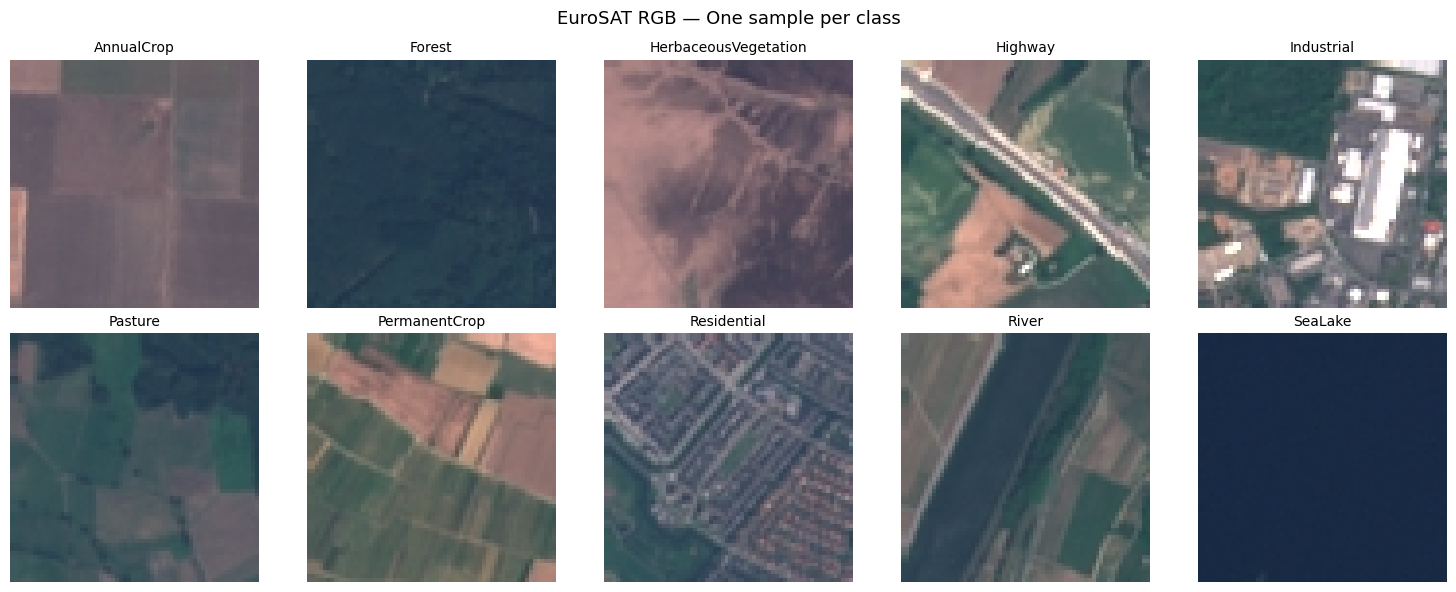

In [10]:
raw_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ])
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

shown = set()
for img, label in raw_dataset:
    if label not in shown:
        axes[label].imshow(img.permute(1, 2, 0).numpy())
        axes[label].set_title(class_names[label], fontsize=10)
        axes[label].axis('off')
        shown.add(label)
    if len(shown) == NUM_CLASSES:
        break

plt.suptitle('EuroSAT RGB — One sample per class', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/user/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:08<00:00, 12.0MB/s]


Total params: 23,528,522
Trainable params: 20,490


In [12]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * images.size(0)
        correct += outputs.max(1)[1].eq(labels).sum().item()
        total += labels.size(0)
    return loss_sum / total, 100.0 * correct / total


def val_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_sum += loss.item() * images.size(0)
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
    return loss_sum / total, 100.0 * correct / total

In [ ]:
def run_stage(model, train_loader, val_loader, epochs, lr, stage_name):
    print(f'\n{"-"*50}')
    print(f'{stage_name} — {epochs} epochs, lr={lr}')
    print(f'{"-"*50}')

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    best_acc = 0.0
    history  = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = val_epoch(model, val_loader, criterion)

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f'Epoch [{epoch:02d}/{epochs}] '
              f'Train: {train_acc:.2f}% | '
              f'Val: {val_acc:.2f}%')

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), '../results/models/resnet50_eurosat.pth')
            print(f'  --> Best model saved ({best_acc:.2f}%)')

    return history, best_acc

In [14]:
import os

In [15]:
os.makedirs('../results/models', exist_ok=True)

history1, best1 = run_stage(
    model, train_loader, val_loader,
    epochs=STAGE1_EPOCHS,
    lr=STAGE1_LR,
    stage_name='Stage 1 — Last layer only'
)


--------------------------------------------------
Stage 1 — Last layer only — 5 epochs, lr=0.01
--------------------------------------------------


/opt/homebrew/Caskroom/miniforge/base/envs/ai/lib/python3.11/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch [01/5] Train: 78.13% | Val: 84.96%
  --> Best model saved (84.96%)
Epoch [02/5] Train: 83.80% | Val: 81.91%
Epoch [03/5] Train: 85.77% | Val: 90.59%
  --> Best model saved (90.59%)
Epoch [04/5] Train: 85.80% | Val: 90.00%
Epoch [05/5] Train: 86.89% | Val: 91.31%
  --> Best model saved (91.31%)
